#### Who Worked on this part? 
Muhammad Azaam Ali,
Aarya Ray Chaudhuri


# Scrape the data

In [1]:
import pandas as pd
from pathlib import Path

# walk up from where the notebook runs to the repo root, so the data path works on every machine
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Mushroom' / 'datasets').is_dir())
DATA = ROOT / 'Mushroom' / 'datasets'
df = pd.read_csv(DATA / 'mushroom_project_dataset.csv')
df.head()

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


We are seeing some NaN cells, which means there are multiple columns with missing data.
### Next steps:
1. Do an EDA to figure out the data distribution.
2. Find out which columns have the most missing data.
3. Figure out number of classes (just to be sure) and class distribution levels.
4. Find fields directly correlated to the class.

# Brief EDA

C:\Users\aarya\AppData\Local\Temp\ipykernel_30752\114234671.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  horizontal_ax = sns.countplot(data=df, x='class', palette=['#2ca02c', '#d62728'])


[Text(0.0, 946.5, '37.9%\n1,893'), Text(1.0, 1553.5, '62.1%\n3,107')]

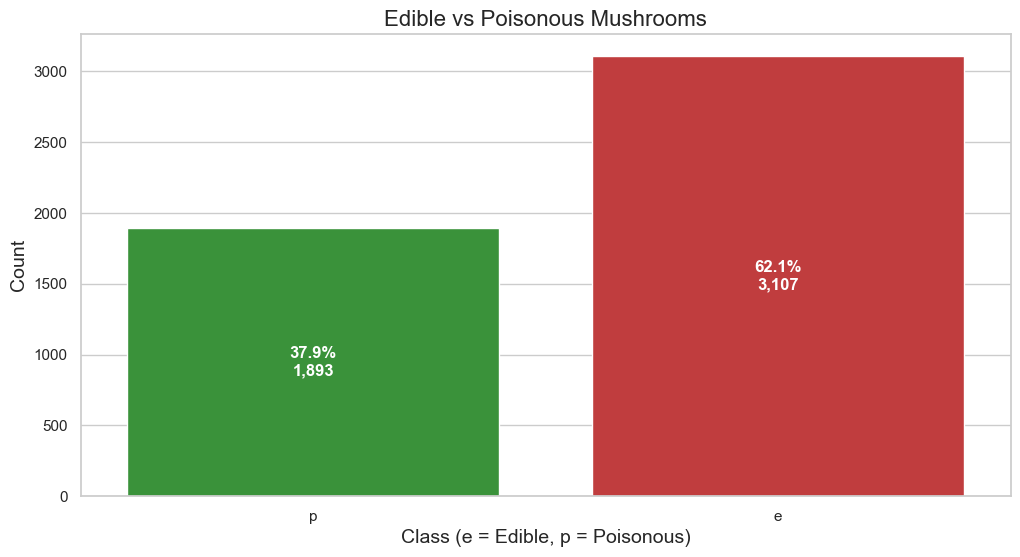

In [2]:
# Finding classes and class distribution
# %pip install seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

horizontal_ax = sns.countplot(data=df, x='class', palette=['#2ca02c', '#d62728'])
plt.title('Edible vs Poisonous Mushrooms', fontsize=16)
plt.xlabel('Class (e = Edible, p = Poisonous)', fontsize=14)
plt.ylabel('Count', fontsize=14)

total = len(df)
[horizontal_ax.annotate(
    f'{100 * p.get_height() / total:.1f}%\n{int(p.get_height()):,}', 
    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
       ha='center', va='center', color='white', fontweight='bold', fontsize=12
) for p in horizontal_ax.patches]
# never use fontsize before or directly after ha, va. attribute 
# error occurs for some reason unknown.



It is confirmed that we have uneven distribution of data in classes. Only 2 classes exist, p and e, and we have 5000 entries.

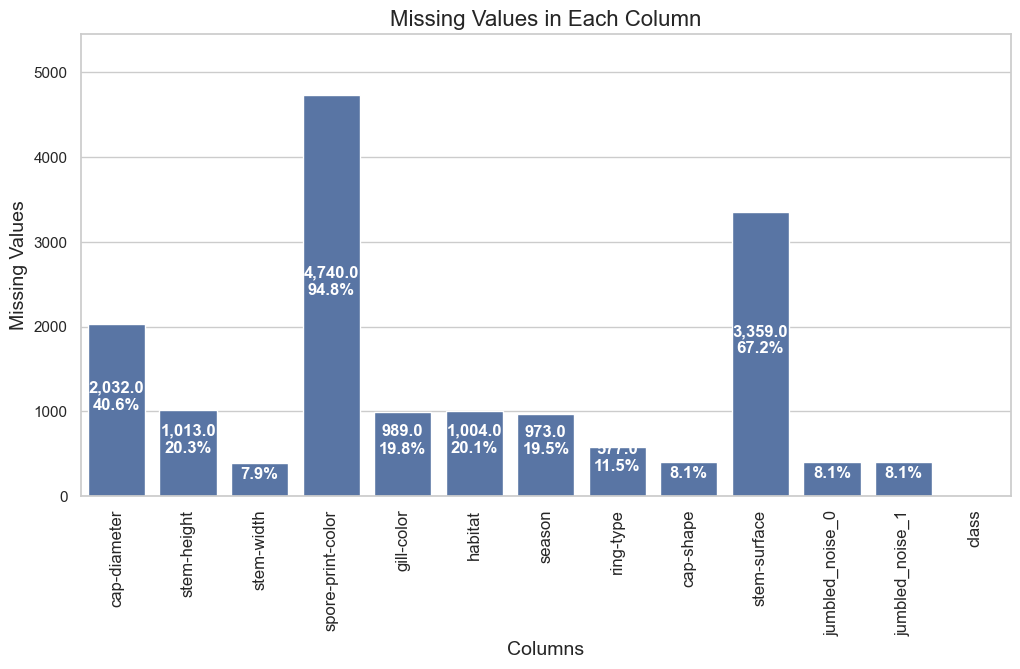

cap-diameter         2032
stem-height          1013
stem-width            395
spore-print-color    4740
gill-color            989
habitat              1004
season                973
ring-type             577
cap-shape             406
stem-surface         3359
jumbled_noise_0       406
jumbled_noise_1       406
class                   0
dtype: int64

In [3]:
# Finding missing values across the columns
missing_values=df.isnull().sum()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Missing Values in Each Column', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Missing Values', fontsize=14)
plt.xticks(rotation=90, fontsize=12, ha='center')

# annotate() formatting for the barplot 
[
    ax.annotate(
            f'{p.get_height():,}\n{(p.get_height() / total) * 100:.1f}%' if p.get_height() > 0 else '0',
            (p.get_x() + p.get_width() / 2., p.get_height() / 2),
            ha='center', va='center', color='white', fontweight='bold', fontsize=12,
            xytext=(0, 10), textcoords='offset points'
    ) for p in ax.patches
]
plt.ylim(0, max(missing_values.values) * 1.15)
plt.show()
missing_values


There is a lot of data missing from the cells especially in the spore-print-color and the stem-surface. Both of these are 95% and 67% empty respectively and can't be used optimally for the model training part apparently.

Main questions:-
 Does having deliberately missing values add any value to a mushroom being edible or poisonous?
 Should we add guess values or not? Mainly to see any change in poisonous class specifically.

In [4]:
# Checking if missing values relate to a poisonous class   
is_poisonous = df['class'] == 'p'

# columns that have at least one missing value
missing_cols = [col for col in df.columns if df[col].isna().any()]

# one row per column: % missing, poisonous rate when missing, poisonous rate when present
missing_vs_class = pd.DataFrame(
    [
        {
            'column': col,
            'pct_missing': round(df[col].isna().mean() * 100, 1),
            'poison_rate_missing': round(is_poisonous[df[col].isna()].mean(), 3),
            'poison_rate_present': round(is_poisonous[df[col].notna()].mean(), 3),
        }
        for col in missing_cols
    ]
).set_index('column').sort_values('pct_missing', ascending=False)

missing_vs_class


,pct_missing,poison_rate_missing,poison_rate_present
column,,,
spore-print-color,94.8,0.373,0.488
stem-surface,67.2,0.355,0.428
cap-diameter,40.6,0.383,0.375
stem-height,20.3,0.378,0.379
habitat,20.1,0.402,0.373
gill-color,19.8,0.381,0.378
season,19.5,0.386,0.377
ring-type,11.5,0.362,0.381
jumbled_noise_0,8.1,0.414,0.375


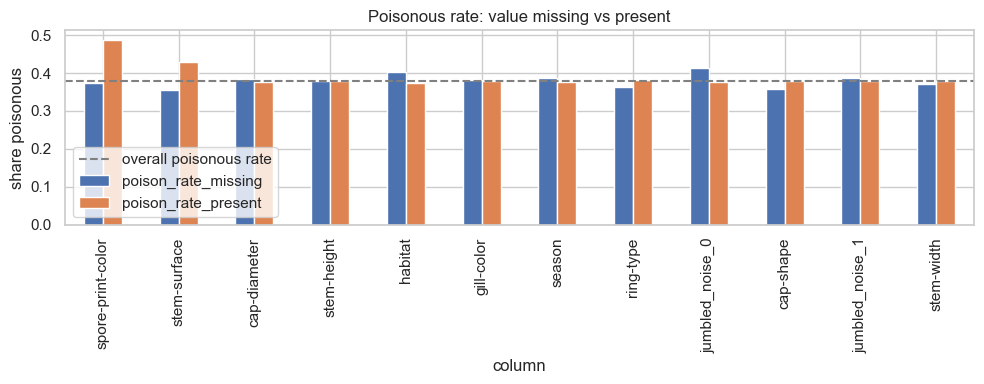

In [5]:
missing_vs_class[['poison_rate_missing', 'poison_rate_present']].plot.bar(figsize=(10, 4))
plt.axhline(is_poisonous.mean(), color='grey', linestyle='--', label='overall poisonous rate')
plt.ylabel('share poisonous')
plt.title('Poisonous rate: value missing vs present')
plt.legend()
plt.tight_layout()
plt.show()

There is not much change when the value is missing or filled overall. The change visually looks random at best. There is no distinct side dominating the graph.

The spore-print-color and stem-surface have the most significant changes, keeping the fact in mind that they were mostly empty.

Features like cap-diameter, stem-height, stem-width, habitat, season, and ring-type have almost the exact same poisonous rate when present vs. missing (~37%–38%), closely matching the global dataset baseline of 37.9%.

Future prediction: self-guessed values may not help us out much, as the visuals tell the story.

! Delete
Hunch: deleting 2 columns, spore print color and stem-surface, may prove to be beneficial when training model.

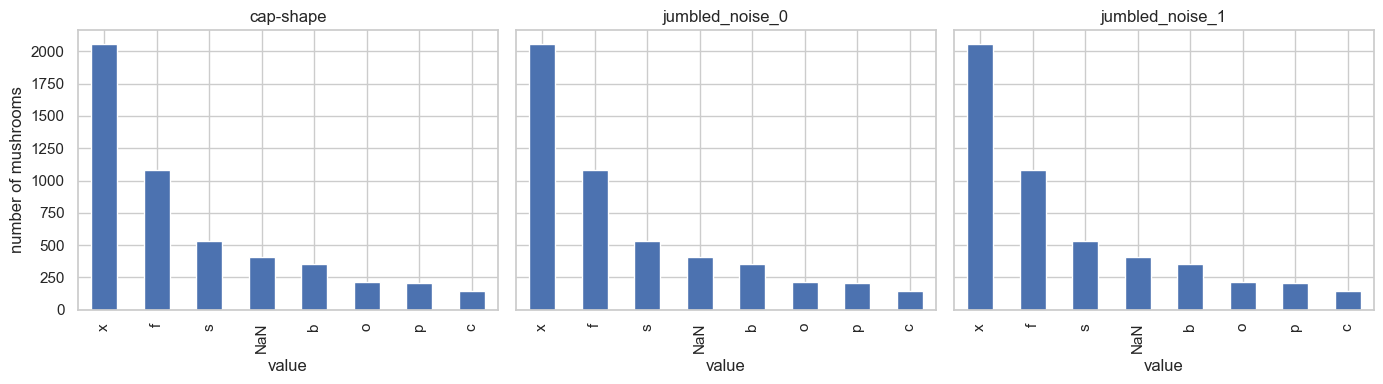

,cap-shape,jumbled_noise_0,jumbled_noise_1
x,2060,2060,2060
f,1078,1078,1078
s,533,533,533
NaN,406,406,406
b,354,354,354
o,218,218,218
p,207,207,207
c,144,144,144


In [6]:
# jumbled_noise columns and cap-shape both share the 
# same number of empty fields (deliberate move?)
# and seeing them in csv makes me think they are 
# randomly exchanged value with cap-shape. Nothing to do with real classes.

cols = ['cap-shape', 'jumbled_noise_0', 'jumbled_noise_1']

counts = pd.DataFrame({col: df[col].fillna('NaN').value_counts() for col in cols})

# same value order for all three, most common value first
counts = counts.sort_values('cap-shape', ascending=False)

# one bar chart per column, side by side, same y-axis so they're easy to compare
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, cols):
    counts[col].plot.bar(ax=ax, title=col)
    ax.set_xlabel('value')
axes[0].set_ylabel('number of mushrooms')
plt.tight_layout()
plt.show()

counts

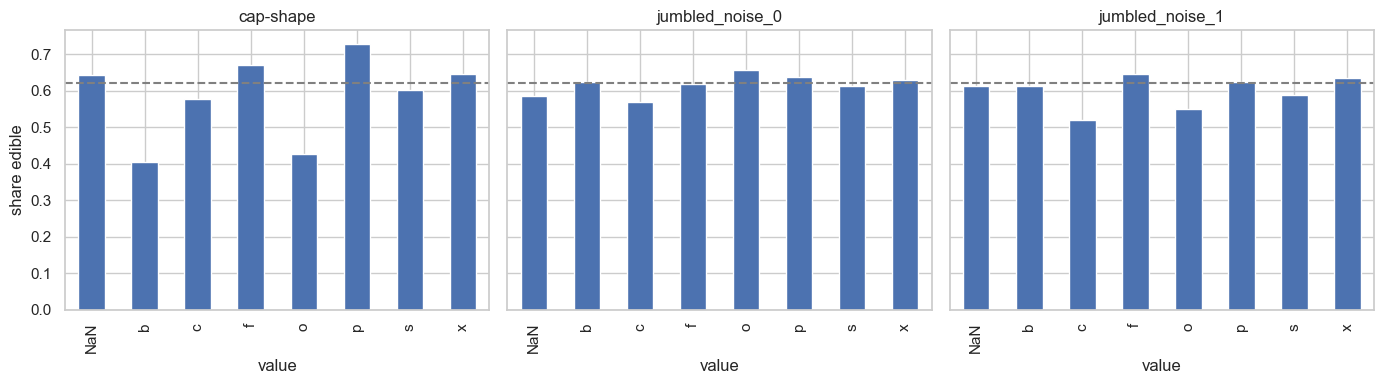

,cap-shape,jumbled_noise_0,jumbled_noise_1
NaN,0.64,0.59,0.61
b,0.40,0.62,0.61
c,0.58,0.57,0.52
f,0.67,0.62,0.65
o,0.43,0.66,0.55
p,0.73,0.64,0.62
s,0.60,0.61,0.59
x,0.65,0.63,0.63


In [7]:
# let's check the edible rate
cols = ['cap-shape', 'jumbled_noise_0', 'jumbled_noise_1']
is_edible = df['class'] == 'e'
edible_rate = pd.DataFrame({col: is_edible.groupby(df[col].fillna('NaN')).mean() for col in cols})

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, cols):
    edible_rate[col].plot.bar(ax=ax, title=col)
    ax.axhline(is_edible.mean(), color='grey', linestyle='--')  # overall edible rate (62%)
    ax.set_xlabel('value')
axes[0].set_ylabel('share edible')
plt.tight_layout()
plt.show()

edible_rate.round(2)

It is plausible that the values are randomly and evenly swapped among the said columns and jumbled-noise-0 and jumbled-noise-1 won't add much value or no value when training the models, as current values don't belong to the right mushroom. Keeping only the cap-shape column as it is helps.

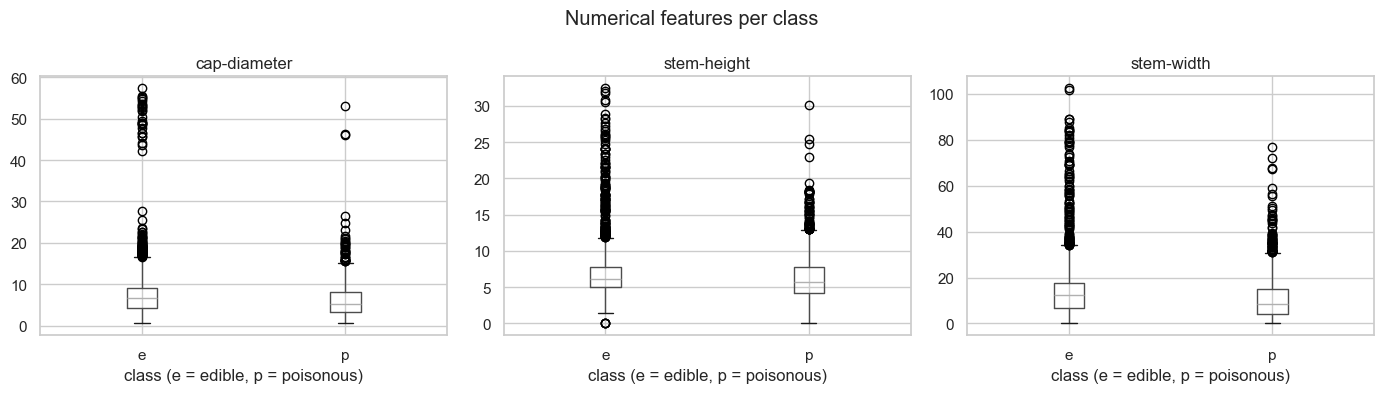

In [8]:
# finding numerical outliers in the columns with numerical values
cols = ['cap-diameter', 'stem-height', 'stem-width']
# df.plot.box(y=cols, title='Boxplots of Numerical Features')

edible = df['class'] == 'e'
poisonous = df['class'] == 'p'

# check numerical outliers for these
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cols):
    df.boxplot(column=col, by='class', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('class (e = edible, p = poisonous)')
plt.suptitle('Numerical features per class')
plt.tight_layout()
plt.show()


In [9]:
# outlier vs percentile
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

def percentile_outliers(s):
    low, high = s.quantile([0.01, 0.99])
    return ((s < low) | (s > high)).sum()

# one row per column and class; quantiles are computed per class here
outliers = pd.DataFrame([
    {
        'column': col,
        'class': name,
        'count': mask_rows.sum(),
        'iqr_outliers': iqr_outliers(df.loc[mask_rows, col].dropna()),
        'pct_outliers': percentile_outliers(df.loc[mask_rows, col].dropna()),
        'max': df.loc[mask_rows, col].max(),
    }
    for col in cols
    for name, mask_rows in [('edible', edible), ('poisonous', poisonous)]
])
outliers


,column,class,count,iqr_outliers,pct_outliers,max
0,cap-diameter,edible,3107,101,38,57.40
1,cap-diameter,poisonous,1893,36,24,53.09
2,stem-height,edible,3107,157,50,32.43
3,stem-height,poisonous,1893,66,16,30.15
4,stem-width,edible,3107,110,57,102.48
5,stem-width,poisonous,1893,71,18,77.00


In [10]:
import numpy as np

pd.DataFrame({
    'skew_original': [df[col].skew() for col in cols],
    'skew_log': [np.log1p(df[col]).skew() for col in cols],
}, index=cols).round(2)


,skew_original,skew_log
cap-diameter,4.23,0.10
stem-height,2.46,-0.76
stem-width,2.60,-0.52


In [11]:
# does the seasonality of the mushroom affect its edibility? not the case. Toxicity is genetic seasons don't change it.
# season representation: unsure about these (s=spring, u=summer), a=autumn, w=winter
# have to ask teach

## What do the letters mean?
The season question above is answered on the [UCI page](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset) of the original dataset. Below are only the codes that actually show up in our file.

| column | codes |
|---|---|
| season | s = spring, u = summer, a = autumn, w = winter |
| cap-shape (and the noise columns) | b = bell, c = conical, x = convex, f = flat, s = sunken, p = spherical, o = others |
| stem-surface | i = fibrous, g = grooves, y = scaly, s = smooth, h = shiny, k = silky, t = sticky, f = none |
| ring-type | e = evanescent, r = flaring, g = grooved, l = large, p = pendant, z = zone, m = movable, f = none |
| habitat | g = grasses, l = leaves, m = meadows, p = paths, h = heaths, u = urban, w = waste, d = woods |
| gill-color, spore-print-color | n = brown, b = buff, g = gray, r = green, p = pink, u = purple, e = red, w = white, y = yellow, o = orange, k = black, f = none |

Also important: cap-diameter and stem-height are in **cm**, but stem-width is in **mm**. That's why stem-width has much bigger numbers than the other two.

## Which columns actually say something about the class?
Up to now we looked at the columns one at a time. To compare all categorical columns at once we use:
- a **chi-square test**: does the edible/poisonous split change between the values of a column? A small p-value means yes.
- **Cramér's V**: how strong that link is, from 0 (no link) to 1 (the column gives the class away).

Missing values are kept as their own category `NaN`, since we saw above that for some columns being empty might mean something.

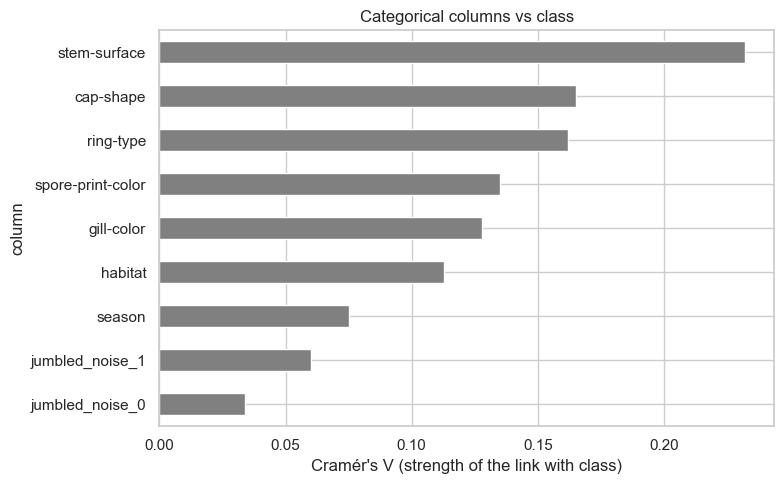

,chi2,p_value,cramers_v
column,,,
stem-surface,268.6,1.918515e-53,0.232
cap-shape,136.4,2.953011e-26,0.165
ring-type,131.1,1.712637e-24,0.162
spore-print-color,90.8,8.353542e-17,0.135
gill-color,81.9,1.826046e-12,0.128
habitat,64.0,7.584240e-11,0.113
season,27.9,1.305072e-05,0.075
jumbled_noise_1,17.7,1.327258e-02,0.060
jumbled_noise_0,5.8,5.609142e-01,0.034


In [12]:
from scipy.stats import chi2_contingency

cat_cols = df.columns.drop(['cap-diameter', 'stem-height', 'stem-width', 'class'])

rows = []
for col in cat_cols:
    table = pd.crosstab(df[col].fillna('NaN'), df['class'])
    chi2, p_value, dof, _ = chi2_contingency(table)
    # with only 2 classes cramer's V simplifies to sqrt(chi2 / n)
    rows.append({'column': col, 'chi2': round(chi2, 1), 'p_value': p_value, 'cramers_v': round(np.sqrt(chi2 / len(df)), 3)})

assoc = pd.DataFrame(rows).set_index('column').sort_values('cramers_v', ascending=False)

ax = assoc['cramers_v'].plot.barh(figsize=(8, 5), color='grey')
ax.invert_yaxis()
ax.set_xlabel("Cramér's V (strength of the link with class)")
ax.set_title('Categorical columns vs class')
plt.tight_layout()
plt.show()

assoc

Every real column is significant (p < 0.001). stem-surface has the strongest link (V ≈ 0.23), followed by cap-shape, ring-type, spore-print-color and gill-color (≈ 0.13 to 0.17). habitat and season are the weakest.

The noise columns behave like noise: jumbled_noise_0 is not significant at all (p ≈ 0.56). jumbled_noise_1 gets p ≈ 0.01, but we run 12 tests here, so one result around 0.01 is what you'd expect by pure chance. With a Bonferroni correction the cut-off becomes 0.05 / 12 ≈ 0.004 and it's out. Together with the identical value counts, this backs up the hunch from earlier: **the noise columns are cap-shape values shuffled between rows** and can be dropped.

The bigger takeaway is that every V is small. The assignment says the UCI version is very deterministic, but here no single column comes close to giving the answer away. A model will have to combine a lot of weak signals.

### Where is the signal hiding?
A low Cramér's V for a whole column can still hide a few values that are very telling. Below is the poisonous rate per value for the four strongest columns. The number of mushrooms is written on each bar, because a rate based on 3 mushrooms doesn't mean much.

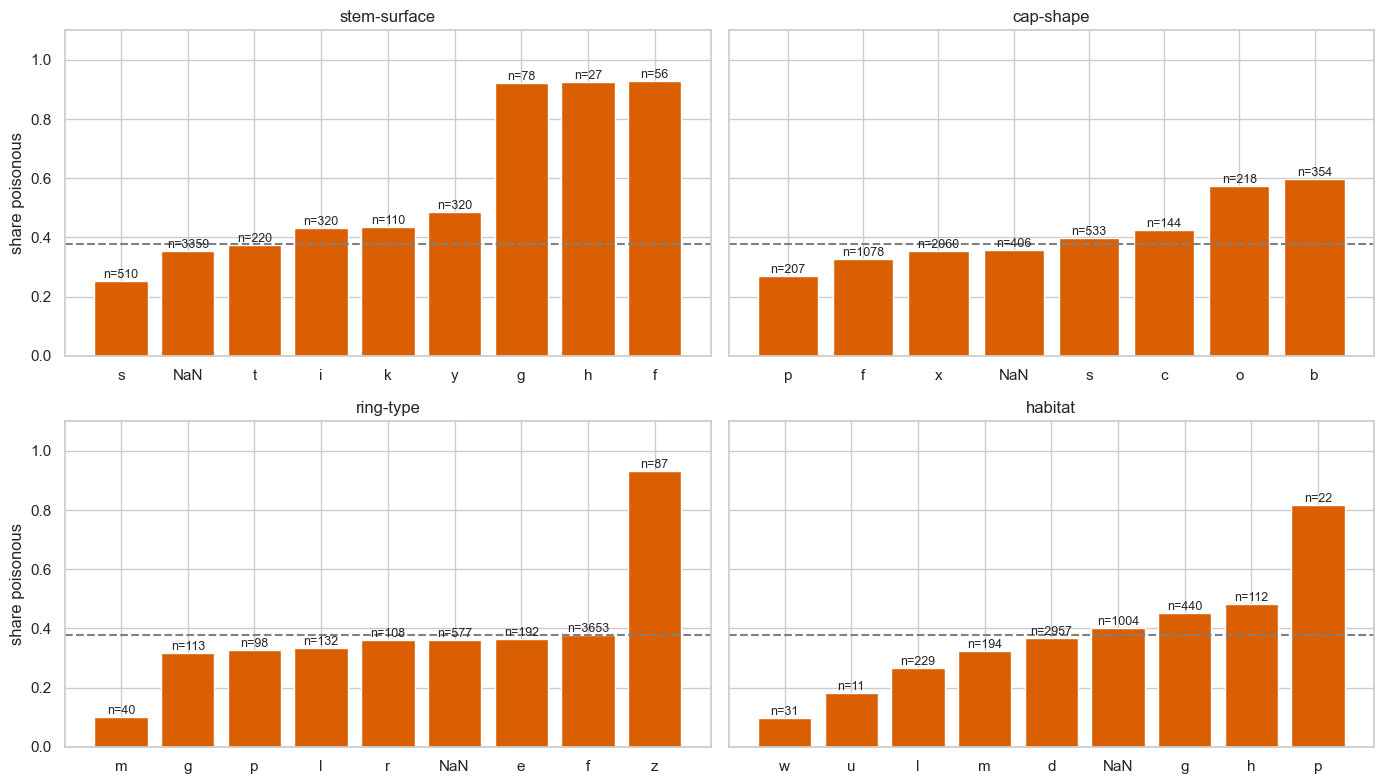

In [13]:
top_cols = ['stem-surface', 'cap-shape', 'ring-type', 'habitat']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, col in zip(axes.flat, top_cols):
    grouped = is_poisonous.groupby(df[col].fillna('NaN')).agg(['mean', 'size']).sort_values('mean')
    bars = ax.bar(grouped.index, grouped['mean'], color='#d95f02')
    ax.bar_label(bars, labels=[f'n={n}' for n in grouped['size']], fontsize=9)
    ax.axhline(is_poisonous.mean(), color='grey', linestyle='--')
    ax.set_title(col)
    ax.set_ylim(0, 1.1)
for ax in axes[:, 0]:
    ax.set_ylabel('share poisonous')
plt.tight_layout()
plt.show()

This is where it gets interesting. Most values sit close to the 38% baseline (dashed line), but a few are almost pure:
- **stem-surface** g (grooves), f (none) and h (shiny) are about 92% poisonous, together 161 mushrooms.
- **ring-type** z (zone) is 93% poisonous (n=87), while m (movable) is only 10% poisonous (n=40).
- **habitat** p (paths) is 82% poisonous, but that's only 22 mushrooms. w (waste) is 10% on 31.
- **cap-shape** b (bell) and o (others) lean poisonous (~60%), p (spherical) leans edible.

These look like single species shining through. The original data has 353 mushrooms per species, and a species is either fully edible or fully poisonous. So a group that is 93% poisonous instead of 100% is a bit suspicious. We come back to that in the section about stemless mushrooms.

## Numerical columns: size matters (a little)
The boxplots above are hard to read because of the skew. log1p takes most of the skew away (see the skew table), so we plot the distributions per class on that scale.

To check whether edible and poisonous really differ we use a **Mann-Whitney U test** instead of a t-test, because the columns are far from normally distributed. The **rank-biserial correlation** tells how big the difference is: 0 = no difference, positive = edible mushrooms tend to be bigger.

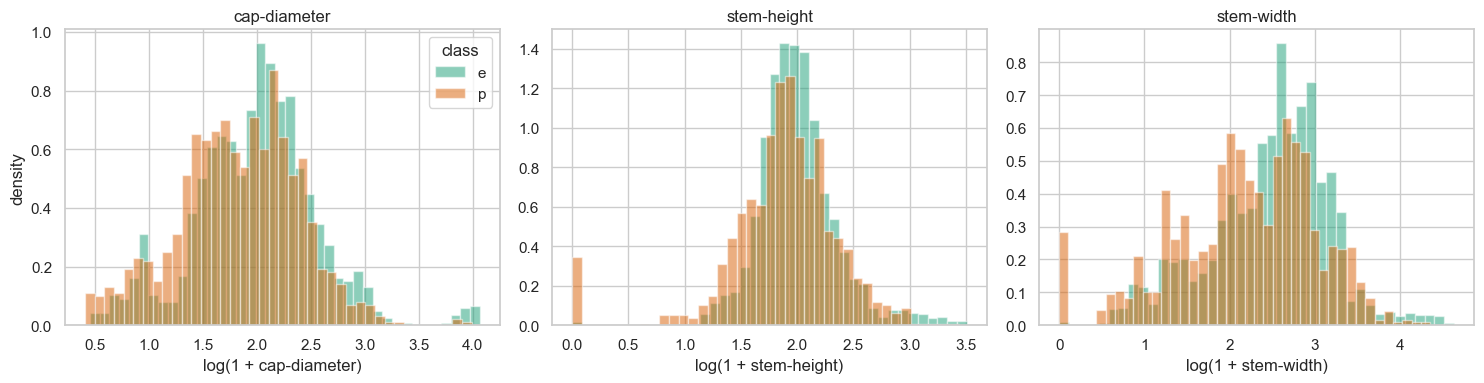

,median_edible,median_poisonous,p_value,rank_biserial
column,,,,
cap-diameter,6.555,5.330,1.118922e-13,0.163
stem-height,6.190,5.725,1.727749e-11,0.127
stem-width,12.265,8.420,8.902634e-32,0.206


In [14]:
from scipy.stats import mannwhitneyu

num_cols = ['cap-diameter', 'stem-height', 'stem-width']
class_colors = {'e': '#1b9e77', 'p': '#d95f02'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for cls, color in class_colors.items():
        values = df.loc[df['class'] == cls, col].dropna()
        ax.hist(np.log1p(values), bins=40, alpha=0.5, color=color, label=cls, density=True)
    ax.set_title(col)
    ax.set_xlabel(f'log(1 + {col})')
axes[0].set_ylabel('density')
axes[0].legend(title='class')
plt.tight_layout()
plt.show()

tests = []
for col in num_cols:
    e_vals = df.loc[edible, col].dropna()
    p_vals = df.loc[poisonous, col].dropna()
    u_stat, p_value = mannwhitneyu(e_vals, p_vals)
    tests.append({
        'column': col,
        'median_edible': e_vals.median(),
        'median_poisonous': p_vals.median(),
        'p_value': p_value,
        'rank_biserial': round(2 * u_stat / (len(e_vals) * len(p_vals)) - 1, 3),
    })
pd.DataFrame(tests).set_index('column')

All three differences are significant (p < 1e-10) and they all point the same way: **poisonous mushrooms are a bit smaller and thinner**. The clearest one is stem-width, with a median of 8.4 mm for poisonous vs 12.3 mm for edible. But the effect sizes are small (0.13 to 0.21) and the histograms overlap almost completely, so size alone won't separate the classes.

Notice the spike at 0 for poisonous stem-height and stem-width. That's not noise, see the stemless section below.

To make "bigger is safer" more concrete, here is the poisonous rate per cap size:

In [15]:
size_bins = pd.cut(df['cap-diameter'], [0, 2, 4, 6, 8, 10, 15, 20, 60])
pd.DataFrame({
    'share_poisonous': is_poisonous.groupby(size_bins, observed=True).mean().round(2),
    'n': size_bins.value_counts().sort_index(),
})

,share_poisonous,n
cap-diameter,,
"(0, 2]",0.46,263
"(2, 4]",0.49,544
"(4, 6]",0.38,632
"(6, 8]",0.33,609
"(8, 10]",0.31,393
"(10, 15]",0.35,362
"(15, 20]",0.25,108
"(20, 60]",0.19,57


Below 4 cm almost half of the mushrooms are poisonous. Above 20 cm it drops to about 1 in 5, but that's only 57 mushrooms. Bigger is safer, not safe.

## The measurements depend on each other
A big mushroom is usually big everywhere, so the three measurements should move together. This matters for cleaning: cap-diameter is missing in 40% of the rows. If it's strongly linked to another column, we can estimate it instead of throwing the column away.

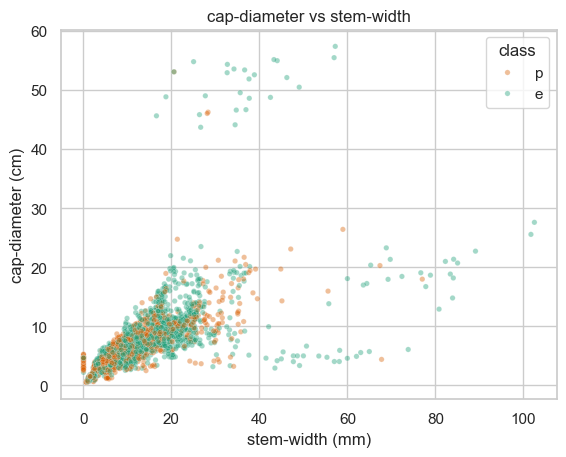

rows missing cap-diameter that still have stem-width: 0.92


,cap-diameter,stem-height,stem-width
cap-diameter,1.00,0.55,0.85
stem-height,0.55,1.00,0.50
stem-width,0.85,0.50,1.00


In [16]:
sns.scatterplot(data=df, x='stem-width', y='cap-diameter', hue='class', palette=class_colors, alpha=0.4, s=15)
plt.title('cap-diameter vs stem-width')
plt.xlabel('stem-width (mm)')
plt.ylabel('cap-diameter (cm)')
plt.show()

print('rows missing cap-diameter that still have stem-width:', round(df.loc[df['cap-diameter'].isna(), 'stem-width'].notna().mean(), 2))
df[num_cols].corr(method='spearman').round(2)

cap-diameter and stem-width have a Spearman correlation of 0.85. The other pairs are around 0.5. On top of that, 92% of the rows that miss cap-diameter still have a stem-width. So **stem-width is a good helper to impute cap-diameter** in the cleaning notebook, which is a lot better than filling in one median for 40% of the data.

The scatter also shows that the big values aren't random outliers. There is a separate group of 31 mushrooms with a cap of 42 to 57 cm (and nothing between 30 and 42 cm). 28 of them are edible and 3 are poisonous. That looks like one giant species, so these values are real and shouldn't be capped. The 3 poisonous ones could be flipped labels again.

## Mushrooms without a stem
Back to the spike at 0. There are 49 rows with stem-height 0 and 57 with stem-width 0. Before calling them errors or outliers, let's see what other values these rows have.

In [17]:
no_stem = (df['stem-height'] == 0) | (df['stem-width'] == 0)
stemless = no_stem | (df['stem-surface'] == 'f')

print('stem-surface of rows with a 0 stem:', df.loc[no_stem, 'stem-surface'].value_counts(dropna=False).to_dict())
print('largest stem-height / stem-width when stem-surface is f:', df.loc[df['stem-surface'] == 'f', ['stem-height', 'stem-width']].max().tolist())
print('ring-type:', df.loc[stemless, 'ring-type'].value_counts(dropna=False).to_dict())
print('habitat:', df.loc[stemless, 'habitat'].value_counts(dropna=False).to_dict())
print('cap-diameter range:', df.loc[stemless, 'cap-diameter'].min(), '-', df.loc[stemless, 'cap-diameter'].max())

df.loc[stemless, 'class'].value_counts()

stem-surface of rows with a 0 stem: {'f': 56, nan: 4}
largest stem-height / stem-width when stem-surface is f: [0.0, 0.0]
ring-type: {'f': 57, nan: 3}
habitat: {'d': 50, nan: 10}
cap-diameter range: 2.19 - 5.28


class
p    56
e     4
Name: count, dtype: int64

Every mushroom with a 0 stem has stem-surface f, which means **none**, or its stem-surface is missing. And every mushroom with stem-surface f has 0 (or missing) stem measurements. So these aren't measuring mistakes: **these mushrooms simply don't have a stem**. They also all have no ring, grow in woods and have a small cap of 2 to 5 cm. That looks like one species. The zeros should not be capped or removed as outliers.

Two things to take into cleaning:
1. The columns fill each other in. stem-surface f means stem-height and stem-width are 0, and a 0 stem means stem-surface is f.
2. Of these 60 stemless mushrooms, 56 are poisonous and only 4 are edible. If this is one species, it should be 100% one class. Those 4 edible ones are very likely **flipped labels**, which the assignment warns about. That's about 7% of the group, a first rough idea of how much label noise there is. It's one small group, so it's an estimate, not a fact.

## Is the missing data random?
Earlier we saw that the poisonous rate barely changes when a value is missing. One more check: if values were removed at random, then a gap in one column should say nothing about a gap in another column. Below is the correlation between the "is missing" flags of all columns.

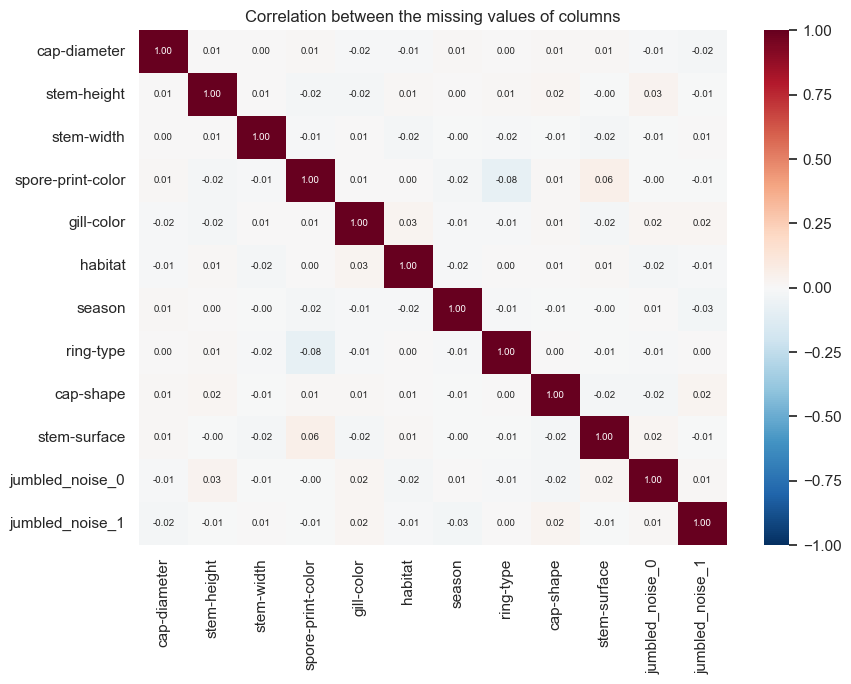

In [18]:
missing_flags = df.drop(columns='class').isna().astype(int)

plt.figure(figsize=(9, 7))
sns.heatmap(missing_flags.corr(), cmap='RdBu_r', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation between the missing values of columns')
plt.tight_layout()
plt.show()

In [19]:
# how many empty cells does each row have?
missing_per_row = missing_flags.sum(axis=1)
core = df.drop(columns=['class', 'jumbled_noise_0', 'jumbled_noise_1', 'spore-print-color', 'stem-surface'])

print('complete rows:', (missing_per_row == 0).sum())
print('complete rows without noise, spore-print-color and stem-surface:', core.notna().all(axis=1).sum())
missing_per_row.value_counts().sort_index()

complete rows: 8
complete rows without noise, spore-print-color and stem-surface: 934


0       8
1     298
2    1093
3    1615
4    1193
5     601
6     156
7      31
8       4
9       1
Name: count, dtype: int64

Apart from the diagonal, the heatmap is basically all zeros. The gaps were punched in **at random, column by column**. Because of that almost every row has a few holes: **only 8 of the 5000 rows are complete**. Even after dropping the noise columns, spore-print-color and stem-surface, only 934 rows (19%) would be complete. Dropping rows with missing values would throw away most of our data, so that's off the table. We will have to impute.

spore-print-color and stem-surface are the exception. In the earlier table their empty rows are clearly less poisonous than their filled rows (37% vs 49% and 36% vs 43%). These two columns were already mostly empty in the original UCI data, because some things were never recorded for some species. So their gaps probably come from the original data and say something about the species, while the gaps in the other columns were added for this assignment. For those two columns, keeping "missing" as its own category might work better than deleting the column. That's something to test in the cleaning notebook.

## Findings.
1. **Target**: 2 classes, 62% edible and 38% poisonous. Not balanced, so plain accuracy will be misleading. In this case a poisonous mushroom predicted as edible is the dangerous mistake, so recall on the poisonous class matters most.
2. **No duplicates**, but **almost every row has missing values**. Only 8 of 5000 rows are complete.
3. **Missing values are random** for 8 of the 10 real columns. The missing flags are uncorrelated with each other and with the class. That means imputing is safe and dropping rows is not an option.
4. **spore-print-color (95% empty) and stem-surface (67% empty) are different.** Their gaps are linked to the class, so "missing" might be a useful category for them.
5. **jumbled_noise_0 and jumbled_noise_1 are shuffled copies of cap-shape.** Same value counts, no significant link with the class after correcting for multiple tests. Drop them.
6. **Every real feature is significant but weak** on its own (Cramér's V 0.08 to 0.23). The strongest are stem-surface, cap-shape and ring-type.
7. **A few values are almost pure**: stem-surface g/f/h and ring-type z are about 92% poisonous, ring-type m and habitat w are about 90% edible.
8. **Poisonous mushrooms are a bit smaller and thinner**, but the effect is small (rank-biserial 0.13 to 0.21).
9. **cap-diameter and stem-width are strongly correlated** (Spearman 0.85). Good for imputing the 40% missing cap-diameter.
10. **Zero stems are real**: 60 stemless mushrooms (stem-surface f = none), not outliers. They also show label noise: 56 poisonous, 4 edible. That's roughly a 7% flip rate inside this group.
11. **Season is coded s/u/a/w = spring/summer/autumn/winter**, and it is the weakest real feature.
12. **Numbers are right-skewed.** log1p brings the skew close to 0 for cap-diameter, which helps distance-based or linear models. Tree models don't care.

### What this means for cleaning
- Drop jumbled_noise_0 and jumbled_noise_1.
- Keep the zero stems and use the stem-surface f ↔ 0 stem rule to fill gaps in both directions.
- Impute cap-diameter from stem-width instead of a global median.
- Try "missing" as its own category for spore-print-color and stem-surface, and compare that with dropping them.
- Don't cap the large values blindly. They are skewed, not wrong (the 42 to 57 cm caps are a real group of 31 mostly edible mushrooms). A log transform is probably the better fix.
- The labels are noisy, so don't trust a model that hits close to 100%. That's more likely overfitting the flipped labels.

# Story
This dataset is a broken copy of a clean one, and most of the EDA came down to finding out how it was broken.

The original UCI data describes 173 species, with every mushroom of a species having the same label. That makes the original easy to predict. Our version was damaged on purpose in four ways, and we found each of them:

**1. Holes were punched in at random.** Cap-diameter alone lost 40% of its values, and only 8 rows are complete. But the gaps don't line up between columns and don't depend on the class. That's good news: the missing data hides information but doesn't mislead, so we can fill it in instead of throwing rows away. The two columns that were already mostly empty in the original (spore-print-color and stem-surface) behave differently. Their gaps do say something about the mushroom.

**2. Fake columns were added.** jumbled_noise_0 and jumbled_noise_1 look real because they use exactly the same letters, in exactly the same amounts, as cap-shape. But the values were shuffled between rows, so they carry no link to the class. They are a trap for anyone who keeps every column.

**3. Signal got weaker.** No single feature predicts the class well anymore. There are pockets of near-certainty, like stemless mushrooms, zone rings and grooved stems that are almost always poisonous. Everything else is a soft trend, like "smaller mushrooms are a bit more likely to be poisonous". The model will have to combine many weak hints.

**4. Some labels were flipped.** The clearest example is the group of 60 stemless mushrooms. They look like a single species, and 56 of them are poisonous but 4 are labelled edible. In the original data that can't happen. So some of our "truth" is wrong, and a model scoring close to 100% would be learning mistakes.

So the story is not "these features make a mushroom poisonous". It's that the information is still there, just hidden under random gaps, fake columns and wrong labels. The cleaning has to uncover it without making things up. And because eating a poisonous mushroom is much worse than skipping an edible one, the model should be judged on how many poisonous mushrooms it catches, not on plain accuracy.